# Setup

In [12]:
import sys
from pathlib import Path

import keras
sys.path.append(Path.cwd().parent.parent.joinpath("src").as_posix())

print(sys.path[-1])
# for p in sys.path:
#   print(p)

DATA_PATH = Path.cwd().parent.parent.joinpath("data/keras")
print(f"DATA_PATH={DATA_PATH}")

import keras
import numpy as np

print('keras', keras.__version__)
print('NumPy', np.__version__)

d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/src
DATA_PATH=d:\workspace\github\hack-modeling\ml\codes\hands-on-ml\data\keras
keras 3.11.3
NumPy 2.3.2


In [32]:
from keras import layers, ops, optimizers, losses, metrics
from keras.utils import to_categorical # Converts a class vector (integers) to binary class matrix.

# Binary classification

In [9]:
# classify movie reviews

# https://keras.io/api/datasets/imdb/
# This is a dataset of 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative).
from keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000) # keep top most frequently words

In [10]:
train_data, train_labels

(array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
        list([1, 194, 1153, 194, 8255, 78, 22

In [23]:
test_data, test_labels

(array([list([1, 591, 202, 14, 31, 6, 717, 10, 10, 2, 2, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 2, 38, 32, 25, 7944, 451, 202, 14, 6, 717]),
        list([1, 14, 22, 3443, 6, 176, 7, 5063, 88, 12, 2679, 23, 1310, 5, 109, 943, 4, 114, 9, 55, 606, 5, 111, 7, 4, 139, 193, 273, 23, 4, 172, 270, 11, 7216, 2, 4, 8463, 2801, 109, 1603, 21, 4, 22, 3861, 8, 6, 1193, 1330, 10, 10, 4, 105, 987, 35, 841, 2, 19, 861, 1074, 5, 1987, 2, 45, 55, 221, 15, 670, 5304, 526, 14, 1069, 4, 405, 5, 2438, 7, 27, 85, 108, 131, 4, 5045, 5304, 3884, 405, 9, 3523, 133, 5, 50, 13, 104, 51, 66, 166, 14, 22, 157, 9, 4, 530, 239, 34, 8463, 2801, 45, 407, 31, 7, 41, 3778, 105, 21, 59, 299, 12, 38, 950, 5, 4521, 15, 45, 629, 488, 2733, 127, 6, 52, 292, 17, 4, 6936, 185, 132, 1988, 5304, 1799, 488, 2693, 47, 6, 392, 173, 4, 2, 4378, 270, 2352, 4, 1500, 7

In [11]:
word_index = imdb.get_word_index()
index_word = dict([(v,k) for (k,v) in word_index.items()])
# 0,1,2: padding, start of sequence, unknown
review = " ".join([index_word.get(i-3, "?") for i in train_data[0]])
review

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [14]:
# prepare data: multi-hot encoding
def vectorize_sequences(sequences, dimension=10000):
  result = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
      result[i,j] = 1.
  return result

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype(np.float32)
y_test = np.asarray(test_labels).astype(np.float32)
x_train, y_train

(array([[0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        ...,
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000)),
 array([1., 0., 0., ..., 0., 1., 0.], shape=(25000,), dtype=float32))

In [17]:
# build model

model = keras.Sequential([
  layers.Dense(16, activation=ops.relu),
  layers.Dense(16, activation=ops.relu),
  layers.Dense(1, activation=ops.sigmoid) # binary output
])

# compile
model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

# fit
val_size = 10000
x_val = x_train[:val_size]
p_x_train = x_train[val_size:]
y_val = y_train[:val_size]
p_y_train = y_train[val_size:]
history = model.fit(p_x_train, p_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
print(history.history)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.7710 - loss: 0.5420 - val_binary_accuracy: 0.8630 - val_loss: 0.4140
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8914 - loss: 0.3432 - val_binary_accuracy: 0.8815 - val_loss: 0.3259
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.9170 - loss: 0.2566 - val_binary_accuracy: 0.8878 - val_loss: 0.2883
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9333 - loss: 0.2079 - val_binary_accuracy: 0.8836 - val_loss: 0.2915
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9454 - loss: 0.1721 - val_binary_accuracy: 0.8813 - val_loss: 0.2929
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9534 - loss: 0.1474 - val_binary_accuracy: 0.8866 - val_loss: 0.2818
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.9601 - loss: 0.1278 - val_binary_accuracy: 0.8839 - val_loss: 0.2980
Epoch 8/20
30

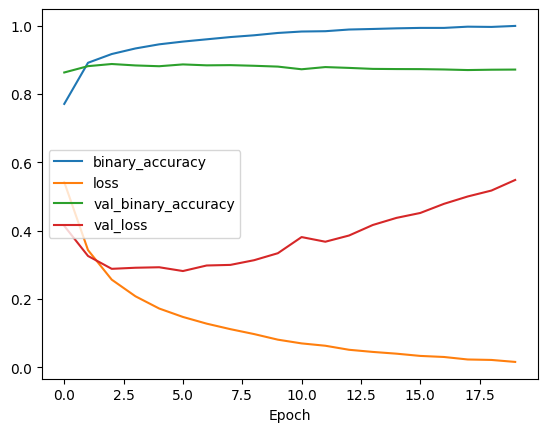

In [22]:
from util.tf import plot_history
plot_history(history)

In [24]:
# retrain a model from scratch
model = keras.Sequential([
  layers.Dense(16, activation=ops.relu),
  layers.Dense(16, activation=ops.relu),
  layers.Dense(1, activation=ops.sigmoid) # binary output
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8139 - loss: 0.4676
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.8999 - loss: 0.2777
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.9204 - loss: 0.2187
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.9328 - loss: 0.1858
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.8872 - loss: 0.2824


In [ ]:
results # (loss, metrics)

[0.2824040353298187, 0.8871600031852722]

In [26]:
# prediction
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.24993345],
       [0.999595  ],
       [0.8610079 ],
       ...,
       [0.10068699],
       [0.08700771],
       [0.5279576 ]], shape=(25000, 1), dtype=float32)

# Multiclass classification

In [ ]:
# newswire topics

# Reuters newswire classification dataset: https://keras.io/api/datasets/reuters/
from keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000) # keep top most frequently words

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [29]:
train_data, train_labels

(array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
        list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
        list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4, 78, 13, 68, 467, 511, 1

In [30]:
test_data, test_labels

(array([list([1, 4, 1378, 2025, 9, 697, 4622, 111, 8, 25, 109, 29, 3650, 11, 150, 244, 364, 33, 30, 30, 1398, 333, 6, 2, 159, 9, 1084, 363, 13, 2, 71, 9, 2, 71, 117, 4, 225, 78, 206, 10, 9, 1214, 8, 4, 270, 5, 2, 7, 748, 48, 9, 2, 7, 207, 1451, 966, 1864, 793, 97, 133, 336, 7, 4, 493, 98, 273, 104, 284, 25, 39, 338, 22, 905, 220, 3465, 644, 59, 20, 6, 119, 61, 11, 15, 58, 579, 26, 10, 67, 7, 4, 738, 98, 43, 88, 333, 722, 12, 20, 6, 19, 746, 35, 15, 10, 9, 1214, 855, 129, 783, 21, 4, 2280, 244, 364, 51, 16, 299, 452, 16, 515, 4, 99, 29, 5, 4, 364, 281, 48, 10, 9, 1214, 23, 644, 47, 20, 324, 27, 56, 2, 2, 5, 192, 510, 17, 12]),
        list([1, 2768, 283, 122, 7, 4, 89, 544, 463, 29, 798, 748, 40, 85, 306, 28, 19, 59, 11, 82, 84, 22, 10, 1315, 19, 12, 11, 82, 52, 29, 283, 1135, 558, 2, 265, 2, 6607, 8, 6607, 118, 371, 10, 1503, 281, 4, 143, 4811, 760, 50, 2088, 225, 139, 683, 4, 48, 193, 862, 41, 967, 1999, 30, 1086, 36, 8, 28, 602, 19, 32, 11, 82, 5, 4, 89, 544, 463, 41, 30, 6273, 13, 2

In [31]:
word_index = reuters.get_word_index()
index_word = dict([(v,k) for (k,v) in word_index.items()])
# 0,1,2: padding, start of sequence, unknown
review = " ".join([index_word.get(i-3, "?") for i in train_data[0]])
review

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step


'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [33]:
# prepare data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# one-hot encoding labels
# def to_one_hot(labels, dimension=46):
#   result = np.zeros((len(labels), dimension))
#   for i, label in enumerate(labels):
#     result[i, label] = 1.
#   return result
# y_train = to_one_hot(train_labels)
# y_test = to_one_hot(test_labels)

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [34]:
x_train, y_train

(array([[0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        ...,
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.]], shape=(8982, 10000)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(8982, 46)))

In [36]:
model = keras.Sequential([
  layers.Dense(64, activation=ops.relu),
  layers.Dense(64, activation=ops.relu),
  layers.Dense(46, activation=ops.softmax) # 46 topics
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.categorical_crossentropy,
              metrics=[metrics.categorical_accuracy])

val_size = 1000
x_val = x_train[:val_size]
p_x_train = x_train[val_size:]
y_val = y_train[:val_size]
p_y_train = y_train[val_size:]
history = model.fit(p_x_train, p_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))
print(history.history)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - categorical_accuracy: 0.4623 - loss: 2.8389 - val_categorical_accuracy: 0.5970 - val_loss: 1.9474
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - categorical_accuracy: 0.6724 - loss: 1.6102 - val_categorical_accuracy: 0.6830 - val_loss: 1.4092
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.7349 - loss: 1.2021 - val_categorical_accuracy: 0.7320 - val_loss: 1.1937
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.7889 - loss: 0.9729 - val_categorical_accuracy: 0.7490 - val_loss: 1.0985
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.8198 - loss: 0.8100 - val_categorical_accuracy: 0.7510 - val_loss: 1.0339
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.8512 - loss: 0.6789 - val_categorical_accuracy: 0.7830 - val_loss: 0.9706
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.8804 - loss: 0.56

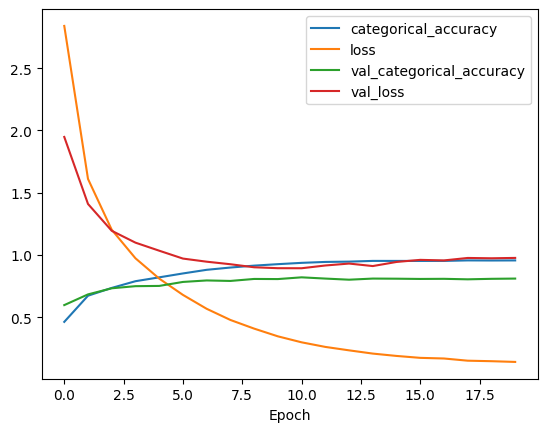

In [37]:
from util.tf import plot_history
plot_history(history)

In [40]:
model = keras.Sequential([
  layers.Dense(64, activation=ops.relu),
  layers.Dense(64, activation=ops.relu),
  layers.Dense(46, activation=ops.softmax)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.categorical_crossentropy,
              metrics=[metrics.categorical_accuracy])

model.fit(x_train, y_train, epochs=9, batch_size=512)

results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.5107 - loss: 2.6507
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.6757 - loss: 1.5205
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.7361 - loss: 1.1818
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.7884 - loss: 0.9709
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.8263 - loss: 0.8078
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.8562 - loss: 0.6727
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.8780 - loss: 0.5618
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.8961 - loss: 0.4783
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.9182 - loss: 0.4015
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.7778 - loss: 0.9549


In [41]:
results

[0.9548783302307129, 0.777827262878418]

In [47]:
predictions = model.predict(x_test)
predictions

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[1.5808881e-04, 3.4060681e-04, 1.1577341e-03, ..., 7.6708930e-05,
        8.7887180e-05, 1.1363705e-05],
       [1.7595366e-03, 3.8873348e-02, 1.1909896e-02, ..., 1.3175190e-05,
        1.4124351e-05, 1.2760446e-03],
       [3.5086111e-03, 8.8809019e-01, 6.2412763e-04, ..., 1.7177782e-04,
        2.2867500e-05, 1.5874902e-03],
       ...,
       [2.4429840e-04, 1.6580279e-03, 3.6312459e-04, ..., 3.3327937e-04,
        6.0111324e-05, 6.5098633e-05],
       [1.4535806e-03, 2.2264006e-02, 4.9778135e-03, ..., 8.2174118e-04,
        5.2836630e-04, 3.8527951e-04],
       [2.4516487e-03, 4.7589135e-01, 9.2993788e-03, ..., 3.6860108e-03,
        3.3939542e-04, 1.3346809e-03]], shape=(2246, 46), dtype=float32)

In [43]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2246, 46))

In [49]:
test_labels

array([ 3, 10,  1, ...,  3,  3, 24], shape=(2246,))

In [54]:
label_names = reuters.get_label_names()
preds = [np.argmax(p) for p in predictions]
mismatch_count = 0
for i in range(len(test_labels)):
  pred_label = np.argmax(predictions[i])
  if pred_label != test_labels[i]:
    mismatch_count += 1
    print(f'mismatch: actual={label_names[test_labels[i]]}, pred={label_names[pred_label]}')
print(f'=== mismatch: {mismatch_count}/{len(test_labels)}')

mismatch: actual=earn, pred=acq
mismatch: actual=acq, pred=crude
mismatch: actual=acq, pred=ship
mismatch: actual=wheat, pred=grain
mismatch: actual=alum, pred=acq
mismatch: actual=earn, pred=acq
mismatch: actual=interest, pred=crude
mismatch: actual=grain, pred=earn
mismatch: actual=dlr, pred=money-fx
mismatch: actual=carcass, pred=trade
mismatch: actual=jobs, pred=reserves
mismatch: actual=grain, pred=earn
mismatch: actual=earn, pred=acq
mismatch: actual=tin, pred=crude
mismatch: actual=gnp, pred=money-fx
mismatch: actual=veg-oil, pred=oilseed
mismatch: actual=pet-chem, pred=crude
mismatch: actual=trade, pred=crude
mismatch: actual=acq, pred=money-fx
mismatch: actual=trade, pred=crude
mismatch: actual=interest, pred=acq
mismatch: actual=livestock, pred=grain
mismatch: actual=money-supply, pred=gas
mismatch: actual=grain, pred=earn
mismatch: actual=interest, pred=acq
mismatch: actual=acq, pred=ship
mismatch: actual=earn, pred=money-fx
mismatch: actual=heat, pred=crude
mismatch: actual

# Regression

In [ ]:
from keras.datasets import boston_housing

# Boston Housing price regression dataset: https://keras.io/2/api/datasets/boston_housing/
# https://lib.stat.cmu.edu/datasets/boston
#  Variables in order:
#  CRIM     per capita crime rate by town                                        <----
#  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
#  INDUS    proportion of non-retail business acres per town
#  CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
#  NOX      nitric oxides concentration (parts per 10 million)
#  RM       average number of rooms per dwelling
#  AGE      proportion of owner-occupied units built prior to 1940
#  DIS      weighted distances to five Boston employment centres
#  RAD      index of accessibility to radial highways
#  TAX      full-value property-tax rate per $10,000
#  PTRATIO  pupil-teacher ratio by town
#  B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
#  LSTAT    % lower status of the population
#  MEDV     Median value of owner-occupied homes in $1000's                      <----
# alternative: https://keras.io/api/datasets/california_housing/
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [ ]:
train_data, train_targets


(array([[1.23247e+00, 0.00000e+00, 8.14000e+00, ..., 2.10000e+01,
         3.96900e+02, 1.87200e+01],
        [2.17700e-02, 8.25000e+01, 2.03000e+00, ..., 1.47000e+01,
         3.95380e+02, 3.11000e+00],
        [4.89822e+00, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
         3.75520e+02, 3.26000e+00],
        ...,
        [3.46600e-02, 3.50000e+01, 6.06000e+00, ..., 1.69000e+01,
         3.62250e+02, 7.83000e+00],
        [2.14918e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
         2.61950e+02, 1.57900e+01],
        [1.43900e-02, 6.00000e+01, 2.93000e+00, ..., 1.56000e+01,
         3.76700e+02, 4.38000e+00]], shape=(404, 13)),
 array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
        17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
        32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
        23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
        12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5

In [57]:
test_data, test_targets

(array([[1.80846e+01, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
         2.72500e+01, 2.90500e+01],
        [1.23290e-01, 0.00000e+00, 1.00100e+01, ..., 1.78000e+01,
         3.94950e+02, 1.62100e+01],
        [5.49700e-02, 0.00000e+00, 5.19000e+00, ..., 2.02000e+01,
         3.96900e+02, 9.74000e+00],
        ...,
        [1.83377e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
         3.89610e+02, 1.92000e+00],
        [3.58090e-01, 0.00000e+00, 6.20000e+00, ..., 1.74000e+01,
         3.91700e+02, 9.71000e+00],
        [2.92400e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
         2.40160e+02, 9.81000e+00]], shape=(102, 13)),
 array([ 7.2, 18.8, 19. , 27. , 22.2, 24.5, 31.2, 22.9, 20.5, 23.2, 18.6,
        14.5, 17.8, 50. , 20.8, 24.3, 24.2, 19.8, 19.1, 22.7, 12. , 10.2,
        20. , 18.5, 20.9, 23. , 27.5, 30.1,  9.5, 22. , 21.2, 14.1, 33.1,
        23.4, 20.1,  7.4, 15.4, 23.8, 20.1, 24.5, 33. , 28.4, 14.1, 46.7,
        32.5, 29.6, 28.4, 19.8, 20.2, 25. , 35.4, 20.3,  9.7

In [59]:
# prepare data: normalize
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

In [60]:
train_data

array([[-0.27224633, -0.48361547, -0.43576161, ...,  1.14850044,
         0.44807713,  0.8252202 ],
       [-0.40342651,  2.99178419, -1.33391162, ..., -1.71818909,
         0.43190599, -1.32920239],
       [ 0.1249402 , -0.48361547,  1.0283258 , ...,  0.78447637,
         0.22061726, -1.30850006],
       ...,
       [-0.40202987,  0.99079651, -0.7415148 , ..., -0.71712291,
         0.07943894, -0.67776904],
       [-0.17292018, -0.48361547,  1.24588095, ..., -1.71818909,
        -0.98764362,  0.42083466],
       [-0.40422614,  2.04394792, -1.20161456, ..., -1.30866202,
         0.23317118, -1.15392266]], shape=(404, 13))

In [ ]:
def build_model():
  model = keras.Sequential([
    layers.Dense(64, activation=ops.relu),
    layers.Dense(64, activation=ops.relu),
    layers.Dense(1)
  ])
  model.compile(optimizer=optimizers.RMSprop(),
                loss=losses.mean_squared_error, # MSE
                metrics=[metrics.mean_absolute_error]) # MAE
  return model

In [66]:
# K-fold validations
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
histories = []
for i in range(k):
  print(f'Processing fold #{i}')
  val_data = train_data[i * num_val_samples: (i+1)*num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i+1)*num_val_samples]
  p_train_data = np.concatenate([train_data[:i * num_val_samples],
                                 train_data[(i+1) * num_val_samples:]],
                                 axis=0)
  p_train_targets = np.concatenate([train_targets[:i * num_val_samples],
                                 train_targets[(i+1) * num_val_samples:]],
                                 axis=0)
  model = build_model()
  history = model.fit(p_train_data, p_train_targets,
            epochs=num_epochs,
            batch_size=16,
            verbose=0)
  histories.append(history)
  val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
  print(val_mse, val_mae)

Processing fold #0
7.9072675704956055 1.974729299545288
Processing fold #1
9.94756031036377 2.4632530212402344
Processing fold #2
14.300333976745605 2.64410138130188
Processing fold #3
12.066621780395508 2.502135992050171


{'loss': [532.4507446289062, 413.82672119140625, 275.6824035644531, 150.20907592773438, 76.79962158203125, 49.67702865600586, 37.95594787597656, 31.25020980834961, 27.242403030395508, 24.48120880126953, 22.363643646240234, 20.43956756591797, 19.325138092041016, 18.374847412109375, 17.09885597229004, 16.47421646118164, 15.431778907775879, 14.91581916809082, 14.341633796691895, 13.749650001525879, 13.441784858703613, 13.03633975982666, 12.393411636352539, 12.308131217956543, 11.94627571105957, 11.705946922302246, 11.673213005065918, 11.13338565826416, 10.839176177978516, 10.625665664672852, 10.811155319213867, 10.118462562561035, 10.39928150177002, 10.151556015014648, 9.978584289550781, 10.00405502319336, 10.035758972167969, 9.580179214477539, 9.653522491455078, 9.431447982788086, 9.412286758422852, 9.259488105773926, 9.34610366821289, 9.063405990600586, 9.069289207458496, 8.767637252807617, 8.940853118896484, 8.557943344116211, 8.627391815185547, 8.69898509979248, 8.238146781921387, 8.6

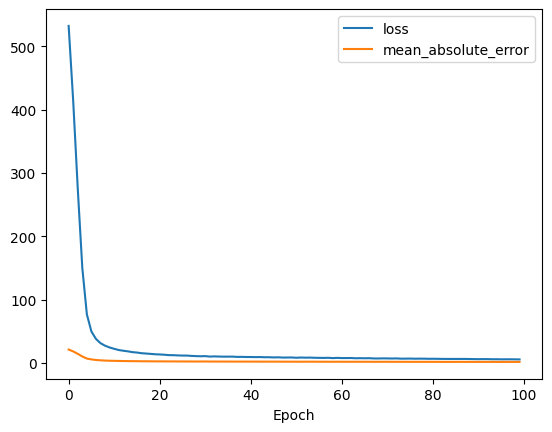

{'loss': [537.0611572265625, 417.03497314453125, 296.923583984375, 181.9637451171875, 103.48763275146484, 66.23146057128906, 50.00497817993164, 39.81148147583008, 33.660213470458984, 28.930076599121094, 25.330522537231445, 22.75455093383789, 20.67413902282715, 18.909807205200195, 17.494348526000977, 16.14845848083496, 15.463865280151367, 14.539148330688477, 13.65408706665039, 13.224942207336426, 12.756651878356934, 12.363208770751953, 12.026212692260742, 11.556124687194824, 11.33402156829834, 10.873030662536621, 10.60898494720459, 10.207761764526367, 10.531268119812012, 10.079370498657227, 9.882473945617676, 9.83474063873291, 9.807902336120605, 9.251237869262695, 9.646598815917969, 9.372486114501953, 9.143445014953613, 9.115710258483887, 8.996377944946289, 8.88786792755127, 8.522637367248535, 8.25499153137207, 8.639718055725098, 8.251094818115234, 8.282173156738281, 8.228137969970703, 8.179285049438477, 7.955225467681885, 8.003609657287598, 7.893474102020264, 7.960712909698486, 7.68198

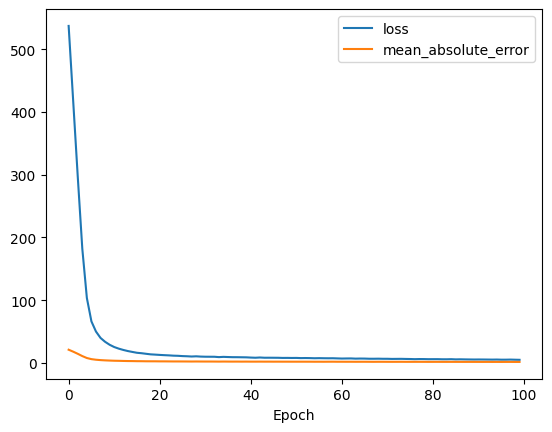

{'loss': [537.6578369140625, 412.0008850097656, 272.2601013183594, 148.89639282226562, 82.690673828125, 55.48160934448242, 40.584991455078125, 31.620424270629883, 26.747007369995117, 23.105693817138672, 20.651182174682617, 18.659683227539062, 17.02202796936035, 15.811373710632324, 14.633440971374512, 13.493233680725098, 12.762948989868164, 12.257929801940918, 11.682402610778809, 11.04188060760498, 10.741106986999512, 10.393328666687012, 9.948790550231934, 9.890850067138672, 9.666142463684082, 9.864106178283691, 9.133663177490234, 9.170805931091309, 9.053686141967773, 8.787917137145996, 8.561871528625488, 8.519367218017578, 8.567675590515137, 8.249214172363281, 8.404353141784668, 8.137589454650879, 7.9496636390686035, 7.7806878089904785, 7.803128242492676, 7.552483558654785, 7.636354446411133, 7.641206741333008, 7.380926132202148, 7.412761211395264, 7.371023654937744, 7.077947616577148, 7.086799621582031, 6.934482574462891, 7.223784923553467, 6.790255069732666, 6.7425994873046875, 6.680

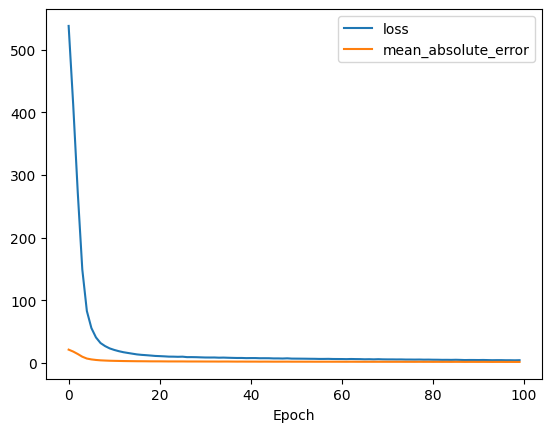

{'loss': [484.60211181640625, 361.1700744628906, 238.7592315673828, 139.11155700683594, 81.6358642578125, 53.47991943359375, 38.86870574951172, 29.903156280517578, 24.709102630615234, 21.411680221557617, 19.28484344482422, 17.292072296142578, 16.410825729370117, 15.089186668395996, 14.236332893371582, 13.394864082336426, 12.878093719482422, 12.45583438873291, 11.633512496948242, 11.401215553283691, 11.054487228393555, 10.726214408874512, 10.452945709228516, 10.224411010742188, 9.834229469299316, 9.821660995483398, 9.502565383911133, 9.433191299438477, 9.426671981811523, 8.927970886230469, 8.894845962524414, 8.770736694335938, 8.873090744018555, 8.495248794555664, 8.43817138671875, 8.283568382263184, 8.474324226379395, 7.979342460632324, 8.456788063049316, 8.076390266418457, 7.981717586517334, 8.071290969848633, 7.723910808563232, 7.94615364074707, 7.6190924644470215, 7.511198997497559, 7.489084720611572, 7.367692470550537, 7.170624256134033, 7.18834114074707, 7.24247932434082, 6.943746

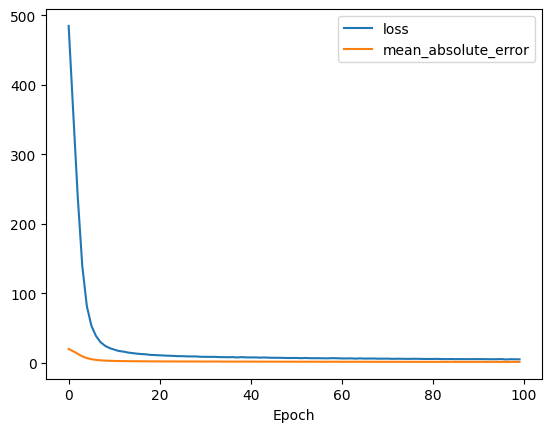

In [71]:
from util.tf import plot_history
for history in histories:
  print(history.history)
  plot_history(history)

In [72]:
model = build_model()
model.fit(train_data, train_targets, epochs=130, batch_size=16, verbose=0)
mse, mae = model.evaluate(test_data, test_targets)
mse, mae

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.3689 - mean_absolute_error: 2.4446


(14.36888313293457, 2.44463849067688)

In [76]:
predictions = model.predict(test_data)
predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[ 8.863339 ],
       [18.556194 ],
       [21.430565 ],
       [31.762047 ],
       [24.673431 ],
       [21.967846 ],
       [26.861801 ],
       [21.359673 ],
       [19.00473  ],
       [21.982256 ],
       [22.075073 ],
       [15.9054   ],
       [15.856919 ],
       [43.07359  ],
       [20.647987 ],
       [19.756216 ],
       [25.844309 ],
       [18.605093 ],
       [19.441864 ],
       [27.15459  ],
       [ 9.986762 ],
       [13.457221 ],
       [21.391716 ],
       [15.983102 ],
       [19.762867 ],
       [23.726362 ],
       [29.377558 ],
       [29.623566 ],
       [11.808301 ],
       [19.604193 ],
       [19.191517 ],
       [14.96053  ],
       [32.434406 ],
       [24.21946  ],
       [19.823406 ],
       [ 7.0776305],
       [16.681612 ],
       [18.154697 ],
       [18.019447 ],
       [25.600914 ],
       [32.80911  ],
       [27.66219  ],
       [12.244431 ],
       [44.00245  ],
       [28.917246 ],
       [26.804234 ],
       [28.674683 ],
       [18.40

In [77]:
predictions.reshape((-1,)) - test_targets

array([  1.66333942,  -0.24380569,   2.43056488,   4.76204681,
         2.4734314 ,  -2.53215408,  -4.33819885,  -1.54032745,
        -1.49526978,  -1.21774406,   3.47507324,   1.40540028,
        -1.94308071,  -6.92641068,  -0.15201263,  -4.54378395,
         1.64430885,  -1.194907  ,   0.34186401,   4.45459061,
        -2.01323795,   3.25722103,   1.391716  ,  -2.51689816,
        -1.13713303,   0.72636223,   1.87755775,  -0.47643433,
         2.30830097,  -2.39580727,  -2.00848312,   0.86053028,
        -0.66559372,   0.81945953,  -0.27659378,  -0.32236948,
         1.28161201,  -5.64530258,  -2.08055267,   1.100914  ,
        -0.19089127,  -0.73781052,  -1.85556946,  -2.69755096,
        -3.58275414,  -2.79576645,   0.27468262,  -1.3962677 ,
         3.25151901,  -2.66855621,   0.07138977,  -0.13110046,
        -0.42916698,  -0.70714951,   0.64754257,   1.48840942,
         3.73751431,  -1.32411194,   0.8269249 ,   1.01376572,
        -7.45327835,   2.46802845, -12.90188122,  -1.46